### CS/ECE/ISyE 524 &mdash; Introduction to Optimization &mdash; Spring 2026 ###

# Project title goes here #

#### Ian Guo (yguo388@wisc.edu), Muxin Li (mli936@wis.edu), Leopold Dong (ldong63@wisc.edu)

### Table of Contents

1. [Introduction](#1.-Introduction)
1. [Mathematical Model](#2.-Mathematical-model)
1. [Implementation and Solution](#3.-Implementation)
1. [Discussion of Results](#4.-Results-discussion)
1. [Optional Subsection](#4.A.-Feel-free-to-add-subsections)
1. [Conclusion](#5.-Conclusion)

## 1. Introduction ##

This project utilizes multi-objective linear programming, specifically the epsilon-constraint method, to design optimal daily diets that minimize both financial cost and greenhouse gas (GHG) emissions. By generating a Pareto frontier, the model illustrates the exact trade-off between eating economically and eating sustainably. Furthermore, we explore how medical dietary restrictions (such as those for diabetes or hypertension) shift this frontier and alter the marginal cost (shadow price) of carbon reduction.
Historically, mathematical diet optimization began with the "Stigler Diet" in 1939, which sought solely to fulfill basic nutritional needs at the absolute minimum monetary cost. Today, the challenge is far more complex. The global food system is responsible for approximately 26% of all global greenhouse gas emissions (Poore & Nemecek, 2018). Because carbon footprints vary wildly between food types, for example, beef emits more carbon per kilogram than plant-based staples exponentially, using optimization to balance affordability, nutrition, and sustainability is a highly relevant tool for modern climate mitigation.
The problem data is integrated from two primary real-world datasets:
- Nutritional Data: We use the CORGIS Food dataset, which provides comprehensive macronutrient profiles (calories, protein, fat, carbs, etc.) across approximately 300 food items.
- Emissions Data: The environmental metrics are sourced from Our World in Data (based on Poore & Nemecek's global meta-analysis), providing kilograms of CO₂ equivalent per kilogram of food for roughly 40 distinct food categories.

### Discussion: 
#### Progress so far
The project has made substantial progress on the core technical components. Specifically, the data pipeline is close to complete: the food nutrition data from the CORGIS dataset and the greenhouse gas emissions data from Our World in Data have both been successfully loaded, cleaned, and merged through the category mapping that links food types (e.g., “beef”, “poultry”, “milk”) to their corresponding emissions values in kg CO2 eq per kilogram. 
The core diet optimization model itself is also implemented in Julia using the JuMP package and the HiGHS optimization solver. The main approach uses the epsilon-constraint method with the goal of fixing a carbon emissions cap and minimizing daily dietary costs. This allows us to construct a Pareto frontier to effectively illustrate a tradeoff between costs and carbon emissions. The model incorporates the baseline nutrition constraints (protein, carbohydrates, and fat/total lipid) and all three of the extensions on health conditions mentioned in our previously submitted project proposal: a general diet for an average healthy person, a diabetic-friendly variant (carbohydrate cap and fiber floor required), and a hypertension variant (sodium and saturated fat caps required). 
In addition, shadow prices on the carbon constraints are also extracted. We are able to look into the cost analysis, specifically, on how much extra daily spending is required to reduce carbon emissions by one additional kilogram. Visually, both the Pareto frontier plot and the shadow price plot are produced for comparison across the three populations’ health condition scenarios.
#### Remaining work
We expect the remaining work to be primarily on interpreting model results and analysis, as well as the write-up of the report. In particular, we will probably add some brief background knowledge to motivate the cost-carbon tradeoff in dietary research, a more detailed description of the two datasets, as well as a roadmap of the report. Next, the Mathematical Model section definitely needs a formal write-up: defining decision variables (daily servings of each food type), the objective function (minimize cost subject to a carbon emissions cap), and all constraints in clean LaTex format. Moreover, the Discussion of Results section is arguably the most important part. After running the model, producing visualizations, and interpreting the Pareto frontiers, we will need to cover: What does the cost-carbon tradeoff look like? How much does adding a special health condition to the diet shift or tighten the frontier? What can shadow prices tell us when reducing carbon emissions becomes extremely expensive? Finally, a Conclusion section would synthesize our key findings, suggest a future direction of research (e.g., additional health conditions, seasonal food availability, or regional pricing), and shed light on implications for policymakers.
#### Rough time estimate
With the model code already running, the remaining work is almost solely on interpretation, analysis, and writing. The Introduction and Mathematical Model sections should be straightforward and take about 2-4 hours total. The Discussion section is most important and thus probably will also take the most time, roughly 3-5 hours, including carefully examining the model results and visualizations, and making connections to the real-world framing of the project. The Conclusions section should be easier and could be done in possibly an hour or two. Altogether, finishing up the project report should be manageable in roughly 6-10 hours of concentrated group work, assuming that no further changes on coding or bug fixes are needed.

### Issues/Concerns
The main concerns are making sure the model produces realistic diet plans and keeping the results interpretable. Balancing each factor (cost, carbon emissions, and nutrition) is important to keep them from overshadowing each other. Creating overly strict constraints could lead to making the optimization problem impossible or output an unrealistic diet (something that satisfies all of the protein, calories, carbon, and cost goals, but is very unpleasant and repetitive to consume. But these issues are definitely solvable by adjusting the weights or modifying the constraints if needed. Specifically, we could create practical serving sizes for each macronutrient. We could also place upper bounds on specific foods or macronutrients, although this could be difficult given the number of foods the dataset provides. The ultimate goal is to keep the final model mathematically correct and practically meaningful.


## 2. Mathematical model ##

A discussion of the modeling assumptions made in the problem (e.g. is it from physics? economics? something else?). Explain the decision variables, the constraints, and the objective function. Finally, show the optimization problem written in standard form. If converting the problem to standard form would create a difficult-to-read model, it is okay to leave it in its simplest original form. Equations should be formatted in $\\LaTeX$ within the IJulia notebook. For this section you may **assume the reader is familiar with the material covered in class**.

Here is an example of an equation:

$$\begin{bmatrix}
      1 & 2 \\
       3 & 4
    \end{bmatrix}
    \begin{bmatrix} x \\ y \end{bmatrix} =
    \begin{bmatrix} 5 \\ 6 \end{bmatrix}$$

And here is an example of an optimization problem in easy-to-read form:
$$\begin{aligned}
  \underset{x \in \mathbb{R^n}}{\text{maximize}}\qquad& f_0(x) \\
    \text{subject to:}\qquad& f_i(x) \le 0 && i=1,\dots,m\\
    & h_j(x) = 0 && j=1,\dots,r
    \end{aligned}$$


## 3. Implementation \& Solutions ##

Here, you should code up your model in Julia + JuMP and solve it. Your code should be clean, easy to read, well annotated and commented, and it should compile! You are not allowed to use other programming languages or DCP packages such as `convex.jl`. I suggest having multiple code blocks separated by text blocks that explain the various parts of your solution. You may want to solve several versions of your problem with different models/assumptions. Suppress any code output that you don't explain in the body of the report.

It's fine to call external packages such as `Gurobi`, but try to minimize the use of exotic libraries.

========== Pareto Frontier and Shadow Price Analysis for Different Populations ==========


Row,Scenario,Carbon_Limit,Actual_Carbon,Cost,Shadow_Price
,String,Float64,Float64,Float64,Float64
1,General,0.145,0.145,2.38,33.519
2,General,0.189,0.189,2.12,2.246
3,General,0.234,0.234,2.02,2.246
4,General,0.278,0.278,1.92,2.246
5,General,0.323,0.323,1.82,2.246
6,General,0.367,0.367,1.72,2.246
7,General,0.412,0.412,1.62,2.246
8,General,0.456,0.456,1.52,2.246
9,General,0.501,0.501,1.43,0.671


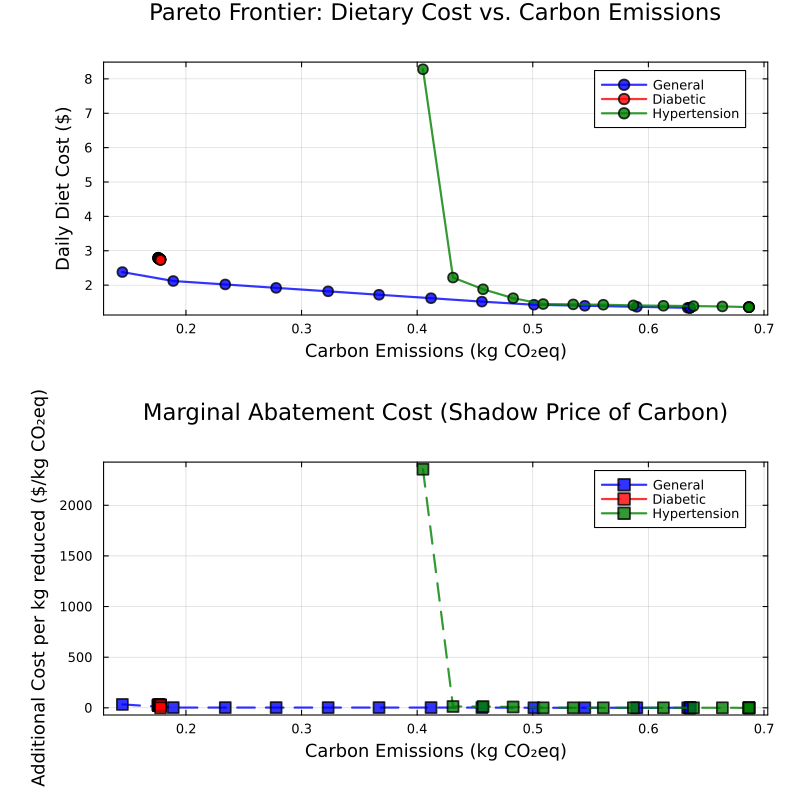

In [28]:
using JuMP, HiGHS, DataFrames, CSV, Plots, Statistics

# ================== 1. Data Preprocessing ==================
food_df = CSV.read("food.csv", DataFrame)
ghg_df = CSV.read("ghg-per-kg-poore.csv", DataFrame)

# Map food categories to GHG entities
mapping = Dict(
    "Milk" => "Milk", "Beef" => "Beef (beef herd)", "Pork" => "Pig Meat",
    "Poultry" => "Poultry Meat", "Eggs" => "Eggs", "Cheese" => "Cheese",
    "Fish" => "Fish (farmed)", "Apples" => "Apples", "Bananas" => "Bananas",
    "Vegetables" => "Other Vegetables", "Nuts" => "Nuts"
)
ghg_lookup = Dict(row.Entity => row."Greenhouse gas emissions per kilogram" for row in eachrow(ghg_df))
food_df.GHG_per_100g = [haskey(mapping, r.Category) && haskey(ghg_lookup, mapping[r.Category]) ? 
                        ghg_lookup[mapping[r.Category]]/10.0 : missing for r in eachrow(food_df)]

# If Price column is missing, create a synthetic one based on typical cost patterns (in $ per 100g)
if !("Price" in names(food_df))
    prices_pattern = [0.8, 4.5, 1.2, 0.9, 2.8, 3.5, 5.5, 0.45, 0.65, 0.75, 1.8, 1.1]
    food_df.Price = [prices_pattern[(i % 12) + 1] for i in 1:nrow(food_df)]
end

# Remove rows with missing GHG data
df = dropmissing(food_df, :GHG_per_100g)
n = nrow(df)

# ================== 2. Core Diet Optimization Model ==================
# Using Epsilon-Constraint method: Fix carbon emission cap and minimize cost
function solve_diet(scenario_name, carbon_limit)
    model = Model(HiGHS.Optimizer)
    set_silent(model) # Suppress solver logs
    
    @variable(model, 0 <= x[1:n] <= 5) # Decision variables: servings of each food (0 to 5)
    
    # Objective function: minimize economic cost only
    @objective(model, Min, sum(x[i] * df[i, :Price] for i in 1:n))
    
    # Core constraint (Epsilon Constraint): set carbon emission cap and name it for Shadow Price extraction
    @constraint(model, carbon_cap, sum(x[i] * df[i, :GHG_per_100g] for i in 1:n) <= carbon_limit)
    
    # Basic nutritional constraints (minimum baseline shared across all populations)
    @constraint(model, sum(x[i] * df[i, :"Data.Protein"] for i in 1:n) >= 50.0)    
    @constraint(model, sum(x[i] * df[i, :"Data.Carbohydrate"] for i in 1:n) >= 130.0) 
    @constraint(model, sum(x[i] * df[i, :"Data.Fat.Total Lipid"] for i in 1:n) >= 40.0)

    # Population-specific constraints (extension based on use case)
    if scenario_name == "Diabetic"
        # Diabetic-friendly: strict daily carbs limit and require high fiber
        @constraint(model, sum(x[i] * df[i, :"Data.Carbohydrate"] for i in 1:n) <= 150.0)
        @constraint(model, sum(x[i] * df[i, :"Data.Fiber"] for i in 1:n) >= 30.0)
    elseif scenario_name == "Hypertension"
        # Hypertension/Heart disease-friendly: strict limits on sodium and saturated fat
        @constraint(model, sum(x[i] * df[i, :"Data.Major Minerals.Sodium"] for i in 1:n) <= 1500.0)
        @constraint(model, sum(x[i] * df[i, :"Data.Fat.Saturated Fat"] for i in 1:n) <= 15.0)
    else # "General"
        # General diet: relaxed standard health guidelines
        @constraint(model, sum(x[i] * df[i, :"Data.Major Minerals.Sodium"] for i in 1:n) <= 2300.0)
    end
    
    optimize!(model)
    
    if termination_status(model) == MOI.OPTIMAL
        min_cost = objective_value(model)
        actual_carbon = value(sum(x[i] * df[i, :GHG_per_100g] for i in 1:n))
        
        # Extract shadow price (Dual Value)
        # Interpretation: dual variables are often negative (for <= constraints with minimization).
        # Their absolute value represents the additional cost per kg reduction in carbon cap.
        shadow_price = abs(dual(carbon_cap)) 
        
        return (actual_carbon, min_cost, shadow_price)
    else
        return (NaN, NaN, NaN)
    end
end

# ================== 3. Calculate Carbon Emission Bounds ==================
# Two optimizations: find the lowest possible carbon emissions while meeting nutrition,
# and the natural carbon emissions when purely minimizing cost
function get_carbon_bounds(scenario_name)
    # This step dynamically corrects distorted Pareto frontiers caused by incorrect value ranges
    
    m = Model(HiGHS.Optimizer); set_silent(m)
    @variable(m, 0 <= x[1:n] <= 5)
    @constraint(m, sum(x[i] * df[i, :"Data.Protein"] for i in 1:n) >= 50.0)
    @constraint(m, sum(x[i] * df[i, :"Data.Carbohydrate"] for i in 1:n) >= 130.0)
    
    if scenario_name == "Diabetic"
        @constraint(m, sum(x[i] * df[i, :"Data.Carbohydrate"] for i in 1:n) <= 150.0)
        @constraint(m, sum(x[i] * df[i, :"Data.Fiber"] for i in 1:n) >= 30.0)
    elseif scenario_name == "Hypertension"
        @constraint(m, sum(x[i] * df[i, :"Data.Major Minerals.Sodium"] for i in 1:n) <= 1500.0)
        @constraint(m, sum(x[i] * df[i, :"Data.Fat.Saturated Fat"] for i in 1:n) <= 15.0)
    else
        @constraint(m, sum(x[i] * df[i, :"Data.Major Minerals.Sodium"] for i in 1:n) <= 2300.0)
    end
    
    # Get minimum carbon emissions value (left boundary)
    @objective(m, Min, sum(x[i] * df[i, :GHG_per_100g] for i in 1:n))
    optimize!(m)
    min_c = termination_status(m) == MOI.OPTIMAL ? objective_value(m) : NaN
    
    # Get maximum carbon emissions at minimum cost (right boundary)
    @objective(m, Min, sum(x[i] * df[i, :Price] for i in 1:n))
    optimize!(m)
    max_c_associated = termination_status(m) == MOI.OPTIMAL ? value(sum(x[i] * df[i, :GHG_per_100g] for i in 1:n)) : NaN
    
    return min_c, max_c_associated
end

# ================== 4. Scan and Collect Pareto Data with Shadow Prices ==================
scenarios = ["General", "Diabetic", "Hypertension"]
results_list = []

for s in scenarios
    min_c, max_c = get_carbon_bounds(s)
    if isnan(min_c)
        println("Warning: $s scenario is infeasible (possible nutrition constraint conflict)")
        continue
    end
    
    # Extract 15 evenly spaced points between minimum and maximum carbon emissions
    epsilon_steps = range(min_c, stop=max_c, length=15)
    
    for cap in epsilon_steps
        c_val, cost_val, sp = solve_diet(s, cap)
        if !isnan(c_val)
            push!(results_list, (Scenario=s, Carbon_Limit=round(cap, digits=3), 
                                 Actual_Carbon=round(c_val, digits=3), 
                                 Cost=round(cost_val, digits=2), 
                                 Shadow_Price=round(sp, digits=3)))
        end
    end
end

results_df = DataFrame(results_list)

# Data clarity: print detailed table for easy reference and complete information display
println("========== Pareto Frontier and Shadow Price Analysis for Different Populations ==========")
display(results_df)

# ================== 5. Generate Dual-Perspective Visualization ==================
# Figure 1: Classic Pareto Frontier plot (cost vs carbon emissions)
plt1 = plot(title="Pareto Frontier: Dietary Cost vs. Carbon Emissions", 
            xlabel="Carbon Emissions (kg CO₂eq)", 
            ylabel="Daily Diet Cost (\$)", 
            legend=:topright, 
            thickness_scaling=1.1, 
            grid=true, framestyle=:box)

# Figure 2: Marginal abatement cost plot (Shadow Price vs carbon emission cap)
plt2 = plot(title="Marginal Abatement Cost (Shadow Price of Carbon)", 
            xlabel="Carbon Emissions (kg CO₂eq)", 
            ylabel="Additional Cost per kg reduced (\$/kg CO₂eq)", 
            legend=:topright,
            thickness_scaling=1.1, 
            grid=true, framestyle=:box)

colors = Dict("General"=>:blue, "Diabetic"=>:red, "Hypertension"=>:green)

for s in scenarios
    sub_df = filter(row -> row.Scenario == s, results_df)
    
    plot!(plt1, sub_df.Actual_Carbon, sub_df.Cost, 
          label=s, color=colors[s], marker=:circle, markersize=5, linewidth=2, alpha=0.8)
          
    plot!(plt2, sub_df.Actual_Carbon, sub_df.Shadow_Price, 
          label=s, color=colors[s], marker=:square, markersize=5, linewidth=2, linestyle=:dash, alpha=0.8)
end

# Stack both plots vertically
final_plot = plot(plt1, plt2, layout=(2, 1), size=(800, 800), margin=5Plots.mm)
display(final_plot)


## 4. Discussion of Results ##

Here, you display and discuss the results. Show figures, tables, plots, images, trade-off curves, or whatever else you can think of to best illustrate your results. The discussion should explain what the results mean, and how to interpret them. You should also explain the limitations of your approach/model and how sensitive your results are to the assumptions you made.

 Use plots (see `Plots` examples from class), or you can display results in a table like this:

| Tables        | Are          | Cool  |
| ------------- |:-------------| -----:|
| col 3 is      |right-aligned |\$1600 |
|  colons       | align columns|  \$12 |
| zebra stripes |    are neat  |   \$1 |

### 4.A. Feel free to add subsections

#### 4.A.a. or subsubsections

## 5. Conclusion ##

Summarize your findings and your results, and talk about at least one possible future direction; something that might be interesting to pursue as a follow-up to your project.